# 04 · Data Visualization — Matplotlib & Seaborn

**Difficulty:** Beginner-Intermediate | **Time:** ~2.5 hours

Good visualizations tell the story your data is hiding. This notebook covers charts used daily in data science.

## Table of Contents
1. Matplotlib Basics
2. Common Chart Types
3. Seaborn for Statistical Plots
4. Subplots & Layouts
5. Styling & Themes
6. Real-world EDA Dashboard
7. Interactive-style with Annotations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Generate a rich dataset for all examples
np.random.seed(42)
n = 200

df = pd.DataFrame({
    'Age'      : np.random.randint(22, 60, n),
    'Salary'   : np.random.normal(65000, 20000, n).clip(20000, 150000).astype(int),
    'Experience': np.random.randint(0, 35, n),
    'Education': np.random.choice(['Bachelor','Master','PhD'], n, p=[0.5, 0.35, 0.15]),
    'Department': np.random.choice(['Engineering','Sales','HR','Marketing','Finance'], n),
    'Gender'   : np.random.choice(['Male','Female'], n),
    'Performance': np.random.choice(['Low','Medium','High'], n, p=[0.2, 0.5, 0.3])
})
# Add correlation: more experience → more salary
df['Salary'] = (df['Salary'] + df['Experience'] * 1500).clip(20000, 160000).astype(int)
print("Dataset ready:", df.shape)
print(df.head())

Dataset ready: (200, 7)
   Age  Salary  Experience Education   Department  Gender Performance
0   50  100560          18    Master        Sales  Female        High
1   36   30500           7       PhD  Engineering    Male         Low
2   29   74639           0  Bachelor           HR  Female      Medium
3   42  115029          21    Master    Marketing  Female        High
4   40   72248          16    Master  Engineering    Male        High


## 1. Matplotlib Basics — Anatomy of a Figure

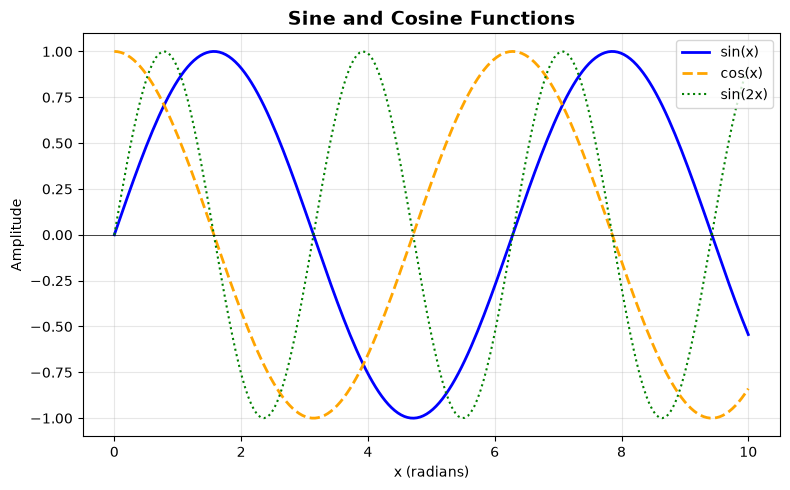

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.linspace(0, 10, 200)

ax.plot(x, np.sin(x),   label='sin(x)',   color='blue',   linewidth=2)
ax.plot(x, np.cos(x),   label='cos(x)',   color='orange', linewidth=2, linestyle='--')
ax.plot(x, np.sin(2*x), label='sin(2x)',  color='green',  linewidth=1.5, linestyle=':')

ax.set_title("Sine and Cosine Functions", fontsize=14, fontweight='bold')
ax.set_xlabel("x (radians)")
ax.set_ylabel("Amplitude")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)  # horizontal line at y=0

plt.tight_layout()
plt.savefig("/tmp/viz_basics.png", dpi=100)
plt.show()

## 2. Common Chart Types

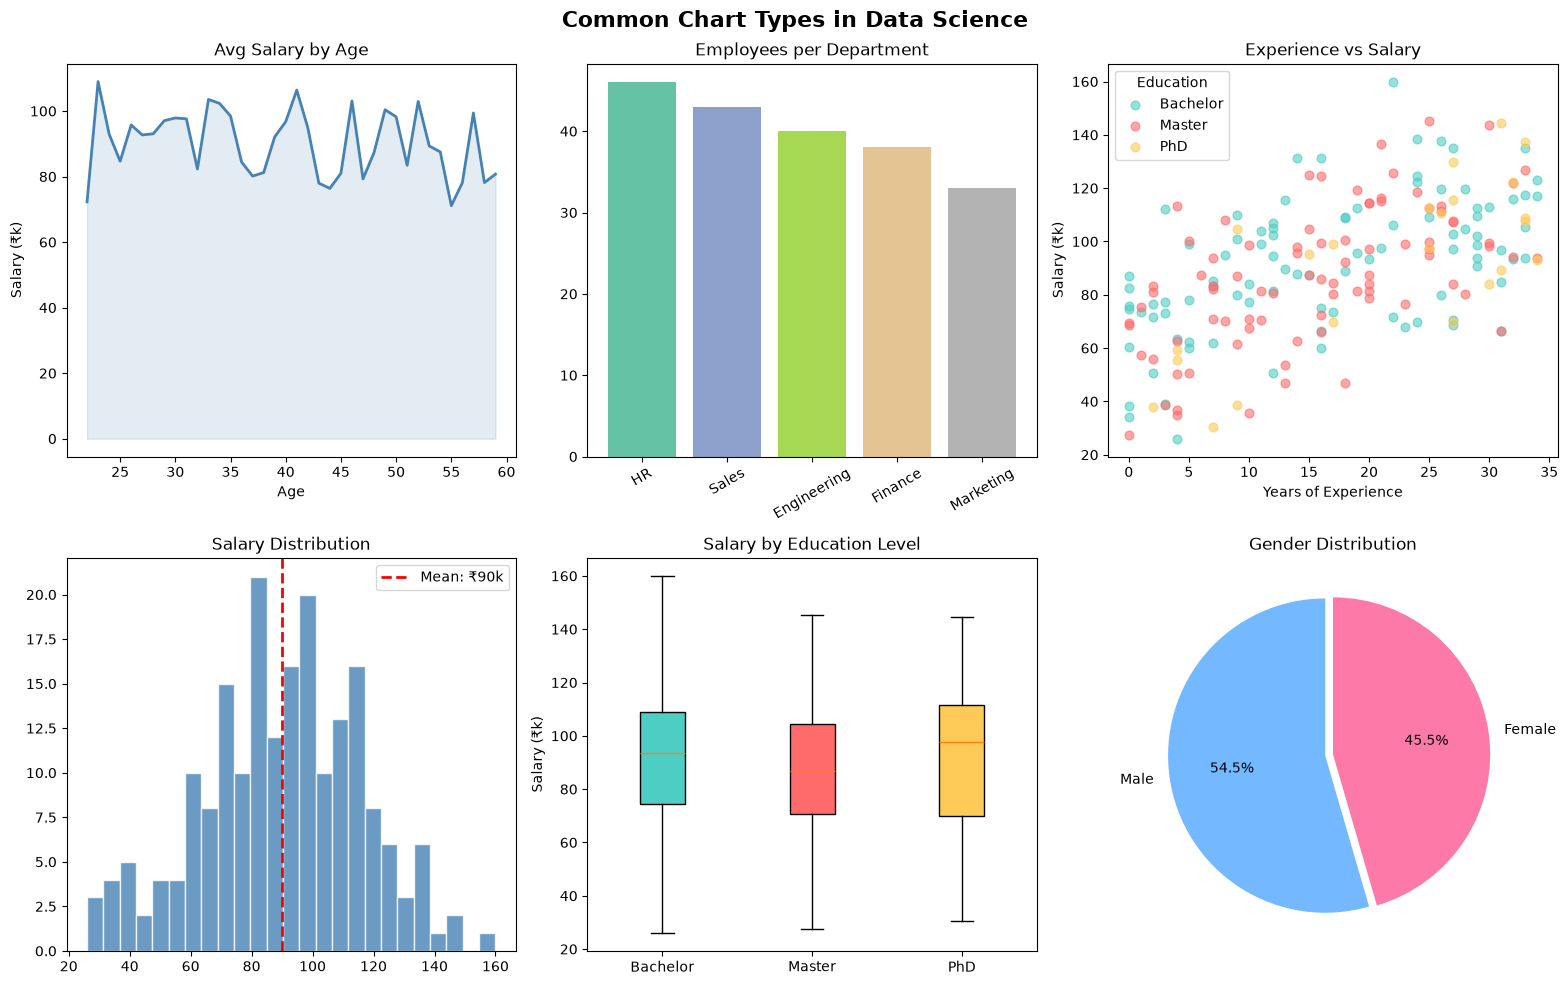

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ── Line Plot: Salary trend with age ──
age_salary = df.groupby('Age')['Salary'].mean().reset_index()
axes[0,0].plot(age_salary['Age'], age_salary['Salary']/1000, color='steelblue', linewidth=2)
axes[0,0].fill_between(age_salary['Age'], age_salary['Salary']/1000, alpha=0.15, color='steelblue')
axes[0,0].set_title("Avg Salary by Age"); axes[0,0].set_xlabel("Age"); axes[0,0].set_ylabel("Salary (₹k)")

# ── Bar Chart: Count per Department ──
dept_counts = df['Department'].value_counts()
colors_bar = plt.cm.Set2(np.linspace(0, 1, len(dept_counts)))
axes[0,1].bar(dept_counts.index, dept_counts.values, color=colors_bar)
axes[0,1].set_title("Employees per Department")
axes[0,1].tick_params(axis='x', rotation=30)

# ── Scatter Plot: Experience vs Salary ──
colors_edu = {'Bachelor':'#4ECDC4','Master':'#FF6B6B','PhD':'#FECA57'}
for edu, grp in df.groupby('Education'):
    axes[0,2].scatter(grp['Experience'], grp['Salary']/1000, 
                       c=colors_edu[edu], label=edu, alpha=0.6, s=40)
axes[0,2].set_title("Experience vs Salary"); axes[0,2].legend(title='Education')
axes[0,2].set_xlabel("Years of Experience"); axes[0,2].set_ylabel("Salary (₹k)")

# ── Histogram: Salary distribution ──
axes[1,0].hist(df['Salary']/1000, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
axes[1,0].axvline(df['Salary'].mean()/1000, color='red', linestyle='--', 
                   linewidth=2, label=f"Mean: ₹{df['Salary'].mean()/1000:.0f}k")
axes[1,0].set_title("Salary Distribution"); axes[1,0].legend()

# ── Box Plot: Salary by Education ──
edu_order = ['Bachelor','Master','PhD']
data_box   = [df[df['Education']==e]['Salary']/1000 for e in edu_order]
bp = axes[1,1].boxplot(data_box, tick_labels=edu_order, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#4ECDC4','#FF6B6B','#FECA57']):
    patch.set_facecolor(color)
axes[1,1].set_title("Salary by Education Level"); axes[1,1].set_ylabel("Salary (₹k)")

# ── Pie Chart: Gender distribution ──
gender_counts = df['Gender'].value_counts()
axes[1,2].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
              colors=['#74b9ff','#fd79a8'], startangle=90, explode=[0.05,0])
axes[1,2].set_title("Gender Distribution")

plt.suptitle("Common Chart Types in Data Science", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/chart_types.png", dpi=100)
plt.show()

## 3. Seaborn — Statistical Visualization

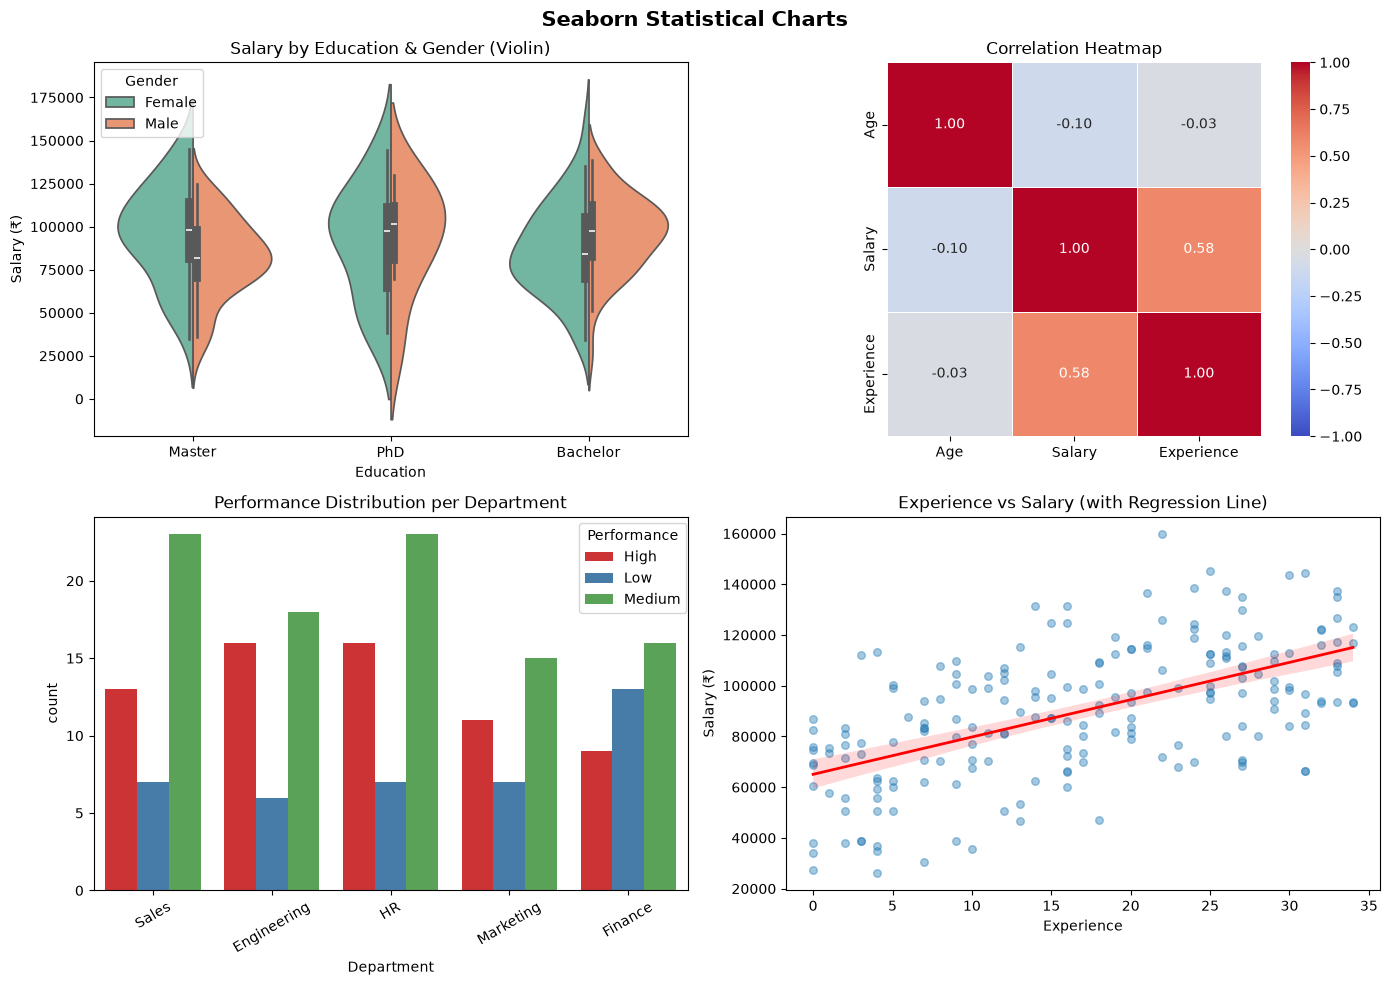

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Violin Plot: richer than box plot ──
sns.violinplot(data=df, x='Education', y='Salary', hue='Gender',
               split=True, ax=axes[0,0], palette='Set2')
axes[0,0].set_title("Salary by Education & Gender (Violin)")
axes[0,0].set_ylabel("Salary (₹)")

# ── Heatmap: Correlation matrix ──
corr = df[['Age','Salary','Experience']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0,1],
            vmin=-1, vmax=1, square=True, linewidths=0.5)
axes[0,1].set_title("Correlation Heatmap")

# ── Count Plot ──
sns.countplot(data=df, x='Department', hue='Performance',
              palette='Set1', ax=axes[1,0])
axes[1,0].set_title("Performance Distribution per Department")
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].legend(title='Performance', bbox_to_anchor=(1.01, 1))

# ── Regplot: Scatter with regression line ──
sns.regplot(data=df, x='Experience', y='Salary', ax=axes[1,1],
            scatter_kws={'alpha':0.4, 's':30}, line_kws={'color':'red','linewidth':2})
axes[1,1].set_title("Experience vs Salary (with Regression Line)")
axes[1,1].set_ylabel("Salary (₹)")

plt.suptitle("Seaborn Statistical Charts", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/seaborn_charts.png", dpi=100)
plt.show()

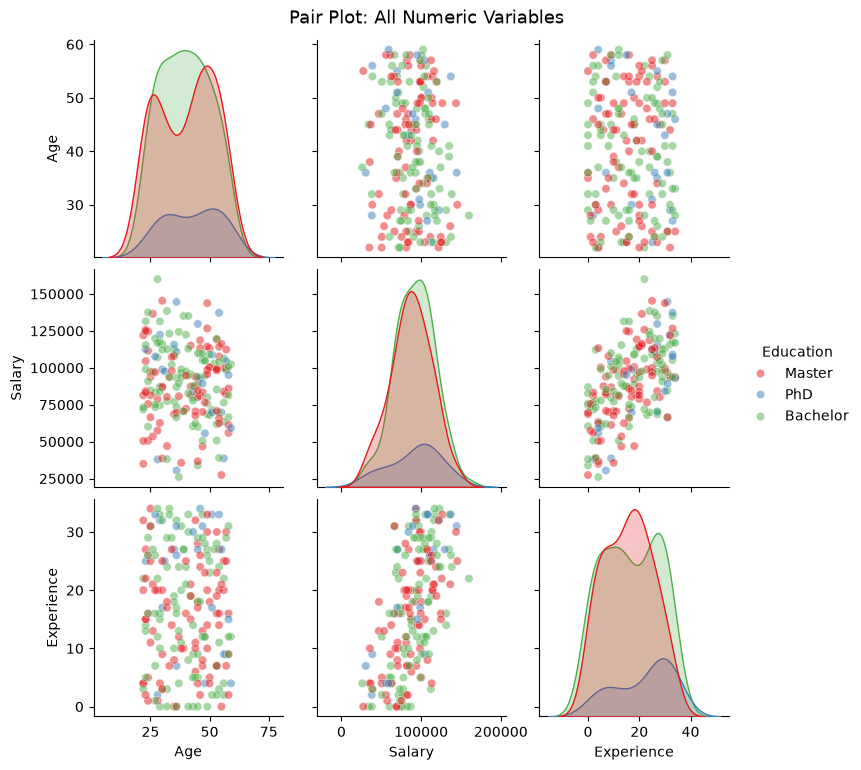

In [5]:
# Pair Plot — see all pairwise relationships at once
numeric_df = df[['Age','Salary','Experience']].copy()
numeric_df['Education'] = df['Education']

g = sns.pairplot(numeric_df, hue='Education', diag_kind='kde',
                 plot_kws={'alpha':0.5}, palette='Set1')
g.fig.suptitle("Pair Plot: All Numeric Variables", y=1.02, fontsize=13)
plt.savefig("/tmp/pairplot.png", dpi=80)
plt.show()

## 4. Real-World EDA Dashboard

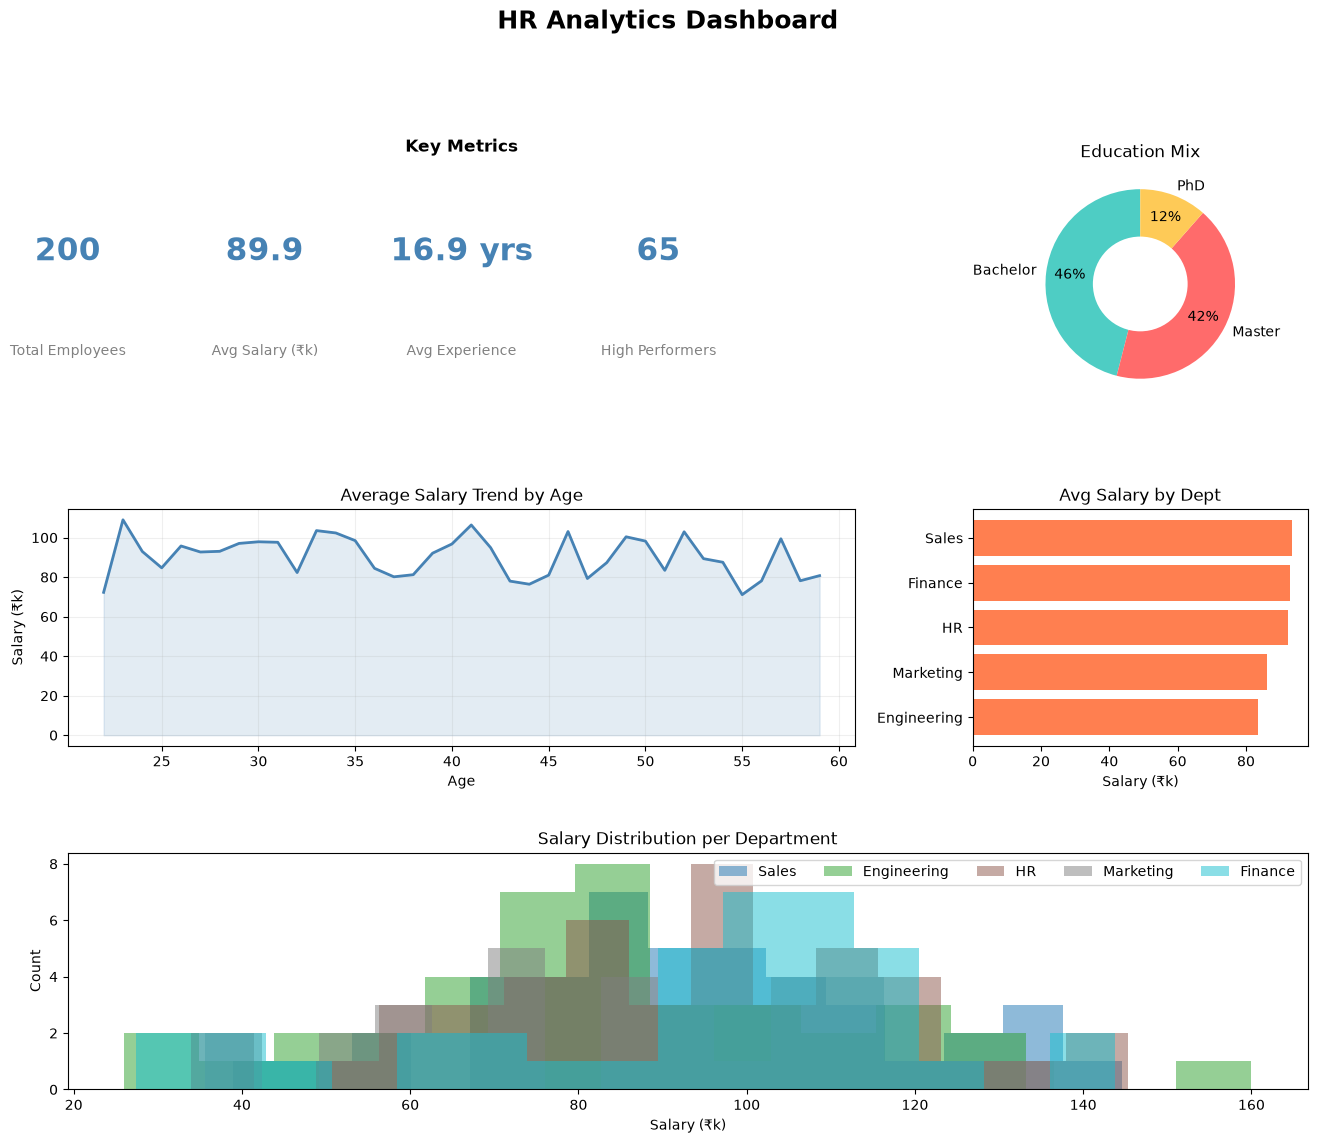

In [6]:
# A full EDA dashboard like you'd present to a stakeholder
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Top-left: KPI Summary ──
ax_kpi = fig.add_subplot(gs[0, :2])
kpis = {
    'Total Employees': len(df),
    'Avg Salary (₹k)': f"{df['Salary'].mean()/1000:.1f}",
    'Avg Experience': f"{df['Experience'].mean():.1f} yrs",
    'High Performers': f"{(df['Performance']=='High').sum()}"
}
ax_kpi.axis('off')
x_pos = 0
for label, val in kpis.items():
    ax_kpi.text(x_pos, 0.6, str(val), fontsize=22, fontweight='bold',
                ha='center', color='steelblue')
    ax_kpi.text(x_pos, 0.2, label, fontsize=10, ha='center', color='gray')
    x_pos += 0.25
ax_kpi.set_title("Key Metrics", fontsize=12, fontweight='bold', pad=10)

# ── Top-right: Education donut ──
ax_donut = fig.add_subplot(gs[0, 2])
edu_counts = df['Education'].value_counts()
wedges, texts, auto = ax_donut.pie(edu_counts, labels=edu_counts.index,
                                    autopct='%1.0f%%', colors=['#4ECDC4','#FF6B6B','#FECA57'],
                                    pctdistance=0.75, startangle=90)
centre = plt.Circle((0,0), 0.5, fc='white')
ax_donut.add_patch(centre)
ax_donut.set_title("Education Mix")

# ── Middle-left: Salary trend ──
ax_trend = fig.add_subplot(gs[1, :2])
age_salary = df.groupby('Age')['Salary'].mean()
ax_trend.plot(age_salary.index, age_salary/1000, color='steelblue', linewidth=2)
ax_trend.fill_between(age_salary.index, age_salary/1000, alpha=0.15, color='steelblue')
ax_trend.set_title("Average Salary Trend by Age")
ax_trend.set_ylabel("Salary (₹k)"); ax_trend.set_xlabel("Age")
ax_trend.grid(True, alpha=0.2)

# ── Middle-right: Department bar ──
ax_dept = fig.add_subplot(gs[1, 2])
dept_sal = df.groupby('Department')['Salary'].mean().sort_values()
ax_dept.barh(dept_sal.index, dept_sal/1000, color='coral')
ax_dept.set_title("Avg Salary by Dept"); ax_dept.set_xlabel("Salary (₹k)")

# ── Bottom: Salary distribution per department ──
ax_dist = fig.add_subplot(gs[2, :])
departments = df['Department'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(departments)))
for dept, color in zip(departments, colors):
    vals = df[df['Department']==dept]['Salary']/1000
    ax_dist.hist(vals, bins=15, alpha=0.5, label=dept, color=color, edgecolor='none')
ax_dist.set_title("Salary Distribution per Department")
ax_dist.set_xlabel("Salary (₹k)"); ax_dist.set_ylabel("Count")
ax_dist.legend(ncol=5)

fig.suptitle("HR Analytics Dashboard", fontsize=18, fontweight='bold', y=1.01)
plt.savefig("/tmp/eda_dashboard.png", dpi=100, bbox_inches='tight')
plt.show()

## 5. Annotations — Telling the Story

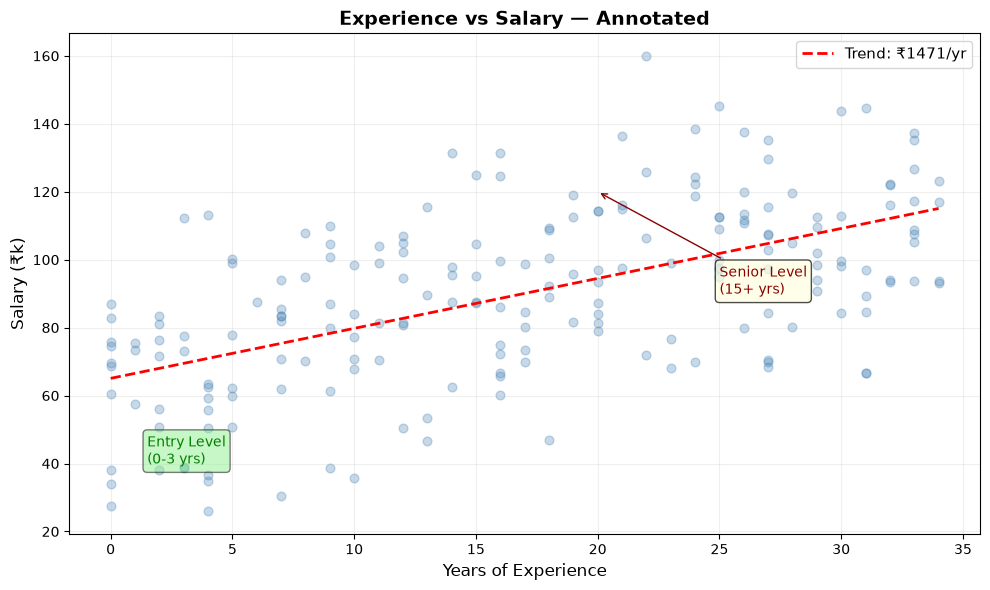

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

# Salary over years of experience
ax.scatter(df['Experience'], df['Salary']/1000, alpha=0.3, s=40, color='steelblue')

# Fit and plot regression line
m, b = np.polyfit(df['Experience'], df['Salary']/1000, 1)
x_range = np.linspace(0, 34, 100)
ax.plot(x_range, m*x_range + b, 'r--', linewidth=2, label=f'Trend: ₹{m*1000:.0f}/yr')

# Annotate key insights
ax.annotate('Entry Level\n(0-3 yrs)', xy=(1.5, 40), fontsize=10, color='green',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.5))
ax.annotate('Senior Level\n(15+ yrs)', xy=(20, 120),
            xytext=(25, 90), fontsize=10, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred'),
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

ax.set_xlabel("Years of Experience", fontsize=12)
ax.set_ylabel("Salary (₹k)", fontsize=12)
ax.set_title("Experience vs Salary — Annotated", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("/tmp/annotated_scatter.png", dpi=100)
plt.show()

## Summary

| Chart Type | Best Used For |
|---|---|
| Line | Trends over time / continuous |
| Bar | Comparing categories |
| Scatter | Relationships between two variables |
| Histogram | Distribution of one variable |
| Box/Violin | Distribution + outliers by group |
| Heatmap | Correlation / 2D density |
| Pair plot | All pairwise relationships |

**Next notebook →** `05_Exploratory_Data_Analysis.ipynb`